## CreditMind — Modelos de Clasificación para Riesgo Crediticio
### Predicción de Default en Préstamos

Este notebook entrena y compara cuatro modelos principales para el prototipo CreditMind:

- Regresión Logística
- Random Forest
- XGBoost
- Red Neuronal

Además, mantiene el Random Forest base como referencia académica y exporta los artefactos necesarios para el dashboard.

### 1. Importar librerías

In [9]:
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

%matplotlib inline
sns.set(style='whitegrid')

### 2. Cargar el dataset limpio

In [10]:
df = pd.read_csv('Loan_default_limpio.csv')

print('Dimensiones:', df.shape)
print('Valores nulos totales:', df.isna().sum().sum())
df.head()

Dimensiones: (255347, 25)
Valores nulos totales: 0


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


### 3. Separar variables predictoras y variable objetivo

In [11]:
FEATURES = [col for col in df.columns if col != 'Default']

X = df[FEATURES]
y = df['Default']

print('Variables seleccionadas:', FEATURES)
print('Total de variables:', len(FEATURES))
print('Variables predictoras (X):', X.shape)
print('Variable objetivo (y):', y.shape)

Variables seleccionadas: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']
Total de variables: 24
Variables predictoras (X): (255347, 24)
Variable objetivo (y): (255347,)


Balance de clases (%):
Default
0    88.39
1    11.61
Name: proportion, dtype: float64


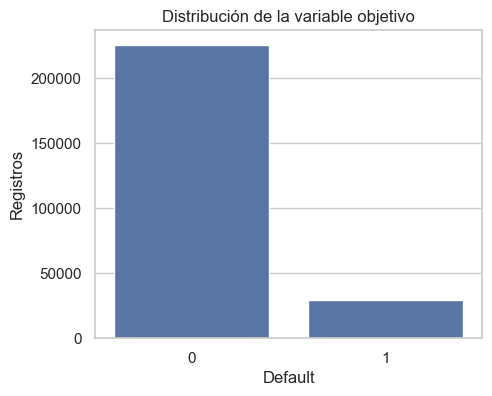

In [12]:
print('Balance de clases (%):')
print(np.round(y.value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title('Distribución de la variable objetivo')
plt.xlabel('Default')
plt.ylabel('Registros')
plt.show()

### 4. Dividir en conjunto de entrenamiento y prueba

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)

Tamaño entrenamiento: (204277, 24)
Tamaño prueba: (51070, 24)


### 5. Random Forest base

In [15]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]

print('Modelo Random Forest base entrenado exitosamente')

Modelo Random Forest base entrenado exitosamente


In [16]:
print('Evaluación Random Forest base')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf_base, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf_base, zero_division=0):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred_rf_base, zero_division=0):.4f}')
print(f'AUC:       {roc_auc_score(y_test, y_prob_rf_base):.4f}')
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred_rf_base, target_names=['No Default', 'Default']))

Evaluación Random Forest base
Accuracy:  0.8849
Precision: 0.7368
Recall:    0.0142
F1-score:  0.0278
AUC:       0.7377
Reporte de Clasificación:
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     45139
     Default       0.74      0.01      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.81      0.51      0.48     51070
weighted avg       0.87      0.88      0.83     51070



### 6. Random Forest optimizado con GridSearchCV

In [17]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('Mejores parámetros Random Forest:')
print(grid_rf.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros Random Forest:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### 7. XGBoost optimizado con GridSearchCV

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print('Mejores parámetros XGBoost:')
print(grid_xgb.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Mejores parámetros XGBoost:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


### 8. Escalado de variables para Regresión Logística, SVM y Red Neuronal

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Escalado completado')
print('X_train_scaled:', X_train_scaled.shape)
print('X_test_scaled:', X_test_scaled.shape)

Escalado completado
X_train_scaled: (204277, 24)
X_test_scaled: (51070, 24)


### 9. Regresión Logística con RandomizedSearchCV

In [20]:
param_dist_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [300]
}

grid_lr = RandomizedSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_dist_lr,
    n_iter=6,
    scoring='f1',
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print('Mejores parámetros Regresión Logística:')
print(grid_lr.best_params_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Mejores parámetros Regresión Logística:
{'solver': 'liblinear', 'max_iter': 300, 'C': 10}


### 10. Support Vector Machine con RandomizedSearchCV

SVM se entrena sobre una submuestra estratificada para evitar tiempos excesivos en datasets grandes.

In [21]:
X_svm, y_svm = resample(
    X_train_scaled,
    y_train,
    replace=False,
    n_samples=int(len(X_train_scaled) * 0.10),
    stratify=y_train,
    random_state=42
)

print(f'Submuestra SVM: {X_svm.shape[0]} filas')
print(f'Balance en submuestra: {dict(zip(*np.unique(y_svm, return_counts=True)))}')

param_dist_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

grid_svm = RandomizedSearchCV(
    estimator=SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_dist_svm,
    n_iter=6,
    scoring='f1',
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

grid_svm.fit(X_svm, y_svm)

print('Mejores parámetros SVM:')
print(grid_svm.best_params_)

best_svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42,
    **grid_svm.best_params_
)

best_svm.fit(X_svm, y_svm)

y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

print('SVM entrenado exitosamente')

Submuestra SVM: 20427 filas
Balance en submuestra: {np.int64(0): np.int64(18055), np.int64(1): np.int64(2372)}
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Mejores parámetros SVM:
{'gamma': 'auto', 'C': 0.1}
SVM entrenado exitosamente


### 11. Red Neuronal con MLPClassifier

Se incorpora una red neuronal multicapa. Como las redes neuronales son sensibles a la escala de las variables, se reutilizan `X_train_scaled` y `X_test_scaled`.

Para mejorar el aprendizaje de la clase minoritaria, se crea una muestra balanceada con todos los casos de default y una muestra equivalente de no default.

In [22]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
y_train_df = y_train.reset_index(drop=True)

train_nn = X_train_scaled_df.copy()
train_nn['Default'] = y_train_df

df_no_default = train_nn[train_nn['Default'] == 0]
df_default = train_nn[train_nn['Default'] == 1]

df_no_default_sample = resample(
    df_no_default,
    replace=False,
    n_samples=len(df_default),
    random_state=42
)

df_nn_balanced = pd.concat([df_no_default_sample, df_default])
df_nn_balanced = df_nn_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_nn_train = df_nn_balanced.drop(columns=['Default'])
y_nn_train = df_nn_balanced['Default']

print('Dataset balanceado para Red Neuronal:')
print(y_nn_train.value_counts())
print('Tamaño:', X_nn_train.shape)

nn_model = MLPClassifier(
    hidden_layer_sizes=(48, 24),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=512,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.15,
    max_iter=80,
    random_state=42
)

nn_model.fit(X_nn_train, y_nn_train)

y_pred_nn = nn_model.predict(X_test_scaled)
y_prob_nn = nn_model.predict_proba(X_test_scaled)[:, 1]

print('Red Neuronal entrenada exitosamente')

Dataset balanceado para Red Neuronal:
Default
0    23722
1    23722
Name: count, dtype: int64
Tamaño: (47444, 24)
Red Neuronal entrenada exitosamente


c:\Users\Antonio\Documents\Curso samsung\Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Antonio\Documents\Curso samsung\Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [23]:
print('Evaluación Red Neuronal')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_nn, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_nn, zero_division=0):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred_nn, zero_division=0):.4f}')
print(f'AUC:       {roc_auc_score(y_test, y_prob_nn):.4f}')
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred_nn, target_names=['No Default', 'Default']))

Evaluación Red Neuronal
Accuracy:  0.6749
Precision: 0.2203
Recall:    0.7088
F1-score:  0.3361
AUC:       0.7541
Reporte de Clasificación:
              precision    recall  f1-score   support

  No Default       0.95      0.67      0.78     45139
     Default       0.22      0.71      0.34      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.67      0.73     51070



### 12. Comparación de modelos

In [24]:
def evaluar_modelo(nombre, y_true, y_pred, y_prob):
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_prob)
    }

resultados = pd.DataFrame([
    evaluar_modelo('Random Forest Base',       y_test, y_pred_rf_base, y_prob_rf_base),
    evaluar_modelo('Random Forest Optimizado', y_test, y_pred_rf,      y_prob_rf),
    evaluar_modelo('XGBoost Optimizado',       y_test, y_pred_xgb,     y_prob_xgb),
    evaluar_modelo('Regresión Logística',      y_test, y_pred_lr,      y_prob_lr),
    evaluar_modelo('SVM',                      y_test, y_pred_svm,     y_prob_svm),
    evaluar_modelo('Red Neuronal',             y_test, y_pred_nn,      y_prob_nn),
])

resultados.sort_values(by='AUC', ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
2,XGBoost Optimizado,0.703427,0.231857,0.671725,0.344726,0.756890
5,Red Neuronal,0.674858,0.220312,0.708818,0.336145,0.754123
1,Random Forest Optimizado,0.729371,0.243531,0.631597,0.351523,0.753788
3,Regresión Logística,0.676444,0.219569,0.699208,0.334193,0.753179
4,SVM,0.683552,0.221981,0.688585,0.335731,0.749151
0,Random Forest Base,0.884923,0.736842,0.014163,0.027792,0.737748


### 13. Matrices de confusión

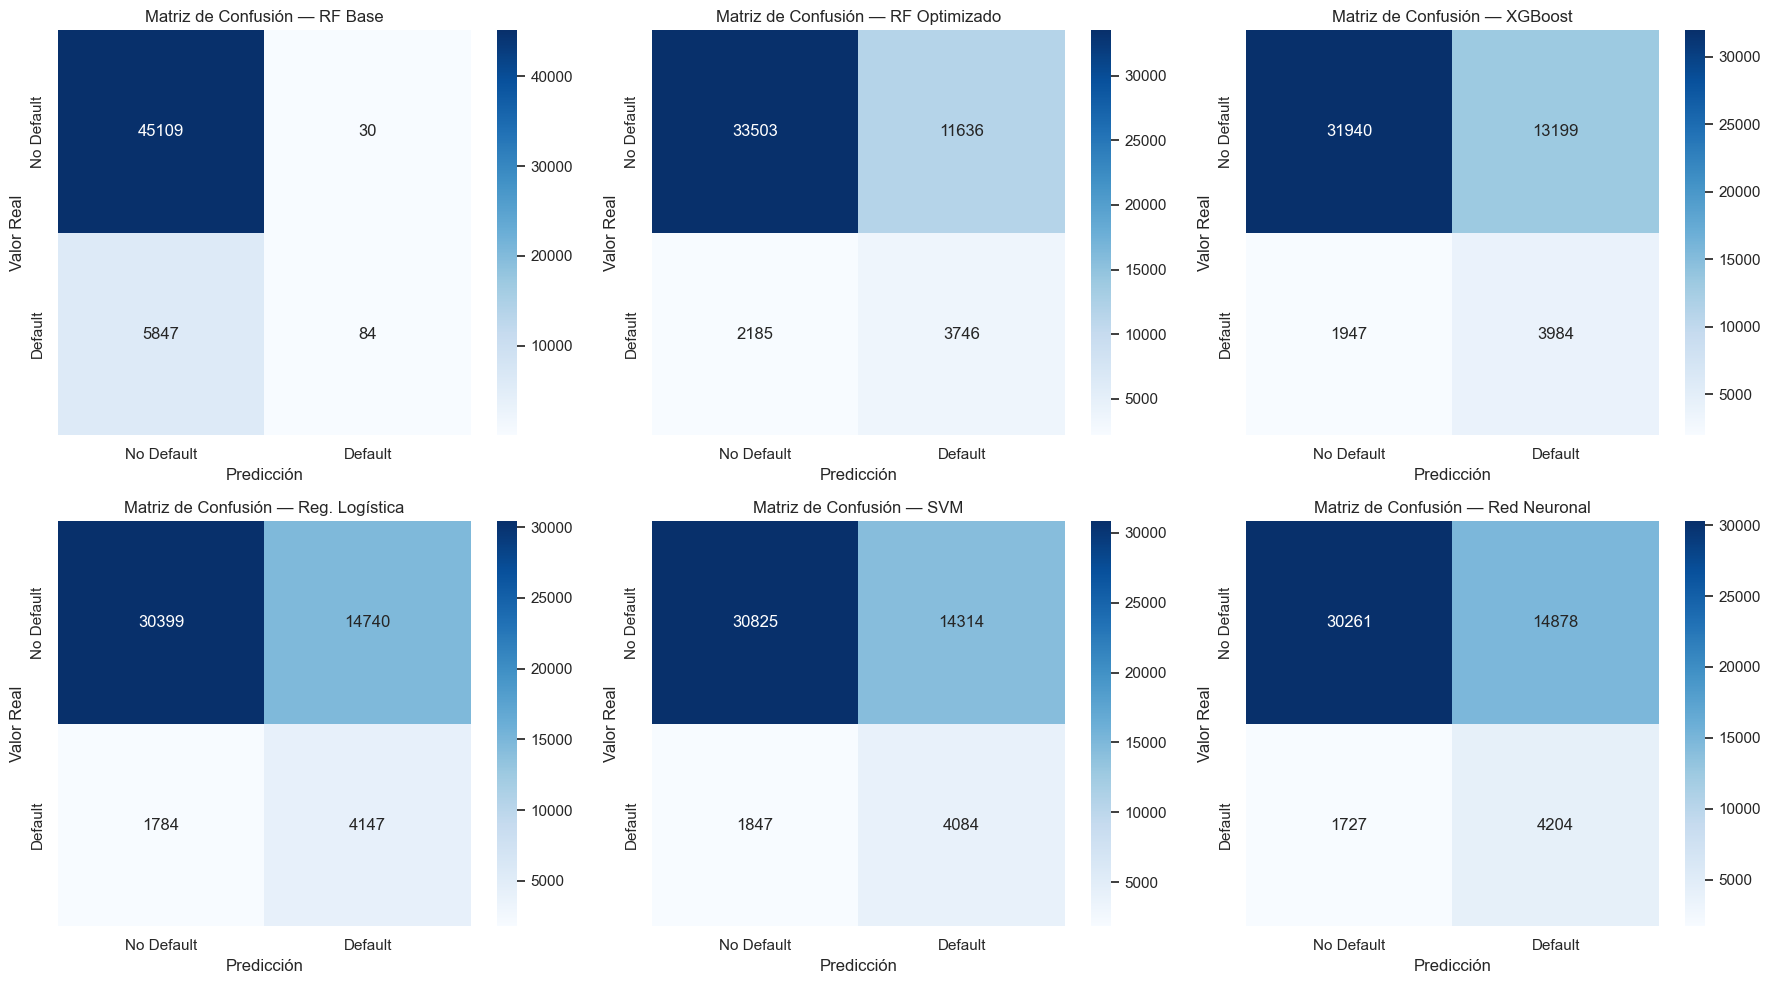

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

matrices = [
    ('RF Base',        confusion_matrix(y_test, y_pred_rf_base)),
    ('RF Optimizado',  confusion_matrix(y_test, y_pred_rf)),
    ('XGBoost',        confusion_matrix(y_test, y_pred_xgb)),
    ('Reg. Logística', confusion_matrix(y_test, y_pred_lr)),
    ('SVM',            confusion_matrix(y_test, y_pred_svm)),
    ('Red Neuronal',   confusion_matrix(y_test, y_pred_nn)),
]

axes = axes.ravel()

for ax, (titulo, matriz) in zip(axes, matrices):
    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['No Default', 'Default'],
        yticklabels=['No Default', 'Default']
    )
    ax.set_title(f'Matriz de Confusión — {titulo}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

### 14. Curva ROC y AUC

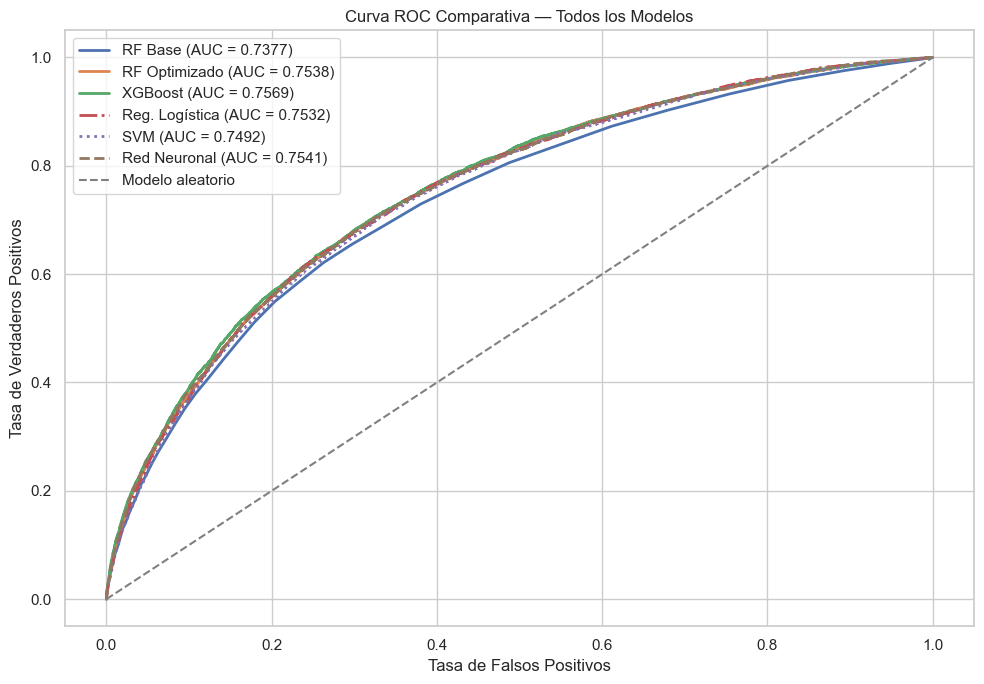

In [26]:
auc_rf_base = roc_auc_score(y_test, y_prob_rf_base)
auc_rf      = roc_auc_score(y_test, y_prob_rf)
auc_xgb     = roc_auc_score(y_test, y_prob_xgb)
auc_lr      = roc_auc_score(y_test, y_prob_lr)
auc_svm     = roc_auc_score(y_test, y_prob_svm)
auc_nn      = roc_auc_score(y_test, y_prob_nn)

fpr_rf_base, tpr_rf_base, _ = roc_curve(y_test, y_prob_rf_base)
fpr_rf, tpr_rf, _           = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _         = roc_curve(y_test, y_prob_xgb)
fpr_lr, tpr_lr, _           = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _         = roc_curve(y_test, y_prob_svm)
fpr_nn, tpr_nn, _           = roc_curve(y_test, y_prob_nn)

plt.figure(figsize=(10, 7))

plt.plot(fpr_rf_base, tpr_rf_base, lw=2, label=f'RF Base (AUC = {auc_rf_base:.4f})')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RF Optimizado (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_lr, tpr_lr, lw=2, linestyle='-.', label=f'Reg. Logística (AUC = {auc_lr:.4f})')
plt.plot(fpr_svm, tpr_svm, lw=2, linestyle=':', label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot(fpr_nn, tpr_nn, lw=2, linestyle='--', label=f'Red Neuronal (AUC = {auc_nn:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Comparativa — Todos los Modelos')
plt.legend()
plt.tight_layout()
plt.show()

### 15. Importancia de variables

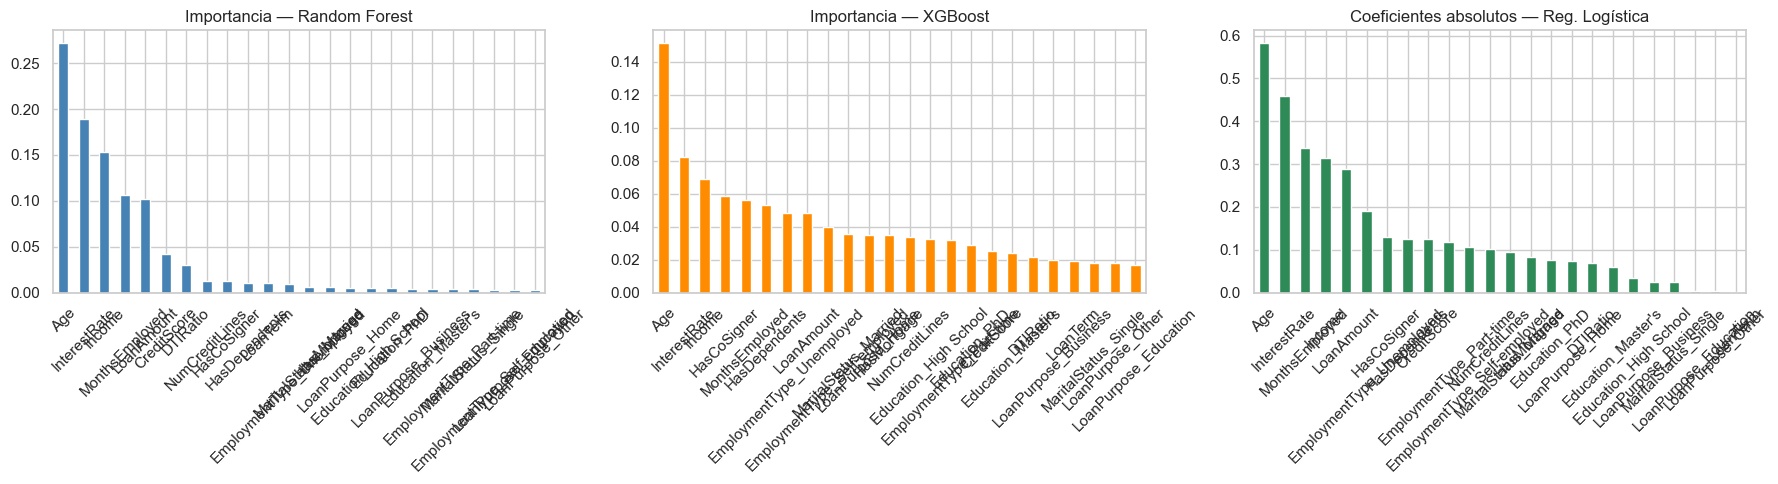

Importancia Random Forest
Age                             0.2722
InterestRate                    0.1889
Income                          0.1533
MonthsEmployed                  0.1065
LoanAmount                      0.1021
CreditScore                     0.0420
DTIRatio                        0.0301
NumCreditLines                  0.0127
HasCoSigner                     0.0124
HasDependents                   0.0109
LoanTerm                        0.0103
EmploymentType_Unemployed       0.0093
MaritalStatus_Married           0.0061
HasMortgage                     0.0057
LoanPurpose_Home                0.0051
Education_High School           0.0051
Education_PhD                   0.0045
LoanPurpose_Business            0.0036
Education_Master's              0.0035
EmploymentType_Part-time        0.0034
MaritalStatus_Single            0.0034
EmploymentType_Self-employed    0.0031
LoanPurpose_Education           0.0031
LoanPurpose_Other               0.0030
dtype: float64
Importancia XGBoost
Age

In [27]:
importancias_rf = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
importancias_xgb = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
importancias_lr = pd.Series(np.abs(best_lr.coef_[0]), index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

importancias_rf.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia — Random Forest')
axes[0].tick_params(axis='x', rotation=45)

importancias_xgb.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Importancia — XGBoost')
axes[1].tick_params(axis='x', rotation=45)

importancias_lr.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Coeficientes absolutos — Reg. Logística')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Importancia Random Forest')
print(np.round(importancias_rf, 4))
print('Importancia XGBoost')
print(np.round(importancias_xgb, 4))
print('Coeficientes absolutos Regresión Logística')
print(np.round(importancias_lr, 4))

### 16. Simulación — evaluación de un cliente

In [28]:
cliente_ejemplo = X_test.iloc[[0]]
cliente_ejemplo_scaled = scaler.transform(cliente_ejemplo)

prob_rf_base = rf_base.predict_proba(cliente_ejemplo)[0][1]
prob_rf      = best_rf.predict_proba(cliente_ejemplo)[0][1]
prob_xgb     = best_xgb.predict_proba(cliente_ejemplo)[0][1]
prob_lr      = best_lr.predict_proba(cliente_ejemplo_scaled)[0][1]
prob_svm     = best_svm.predict_proba(cliente_ejemplo_scaled)[0][1]
prob_nn      = nn_model.predict_proba(cliente_ejemplo_scaled)[0][1]

simulacion = pd.DataFrame({
    'Modelo': ['RF Base', 'RF Optimizado', 'XGBoost', 'Regresión Logística', 'SVM', 'Red Neuronal'],
    'Probabilidad Default': [prob_rf_base, prob_rf, prob_xgb, prob_lr, prob_svm, prob_nn]
})

simulacion['Probabilidad Default (%)'] = np.round(simulacion['Probabilidad Default'] * 100, 2)
simulacion

c:\Users\Antonio\Documents\Curso samsung\Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


,Modelo,Probabilidad Default,Probabilidad Default (%)
0,RF Base,0.070000,7.00
1,RF Optimizado,0.304143,30.41
2,XGBoost,0.221513,22.15
3,Regresión Logística,0.186317,18.63
4,SVM,0.045213,4.52
5,Red Neuronal,0.180354,18.04


In [29]:
probabilidad = prob_xgb

print('=== Decisión final basada en XGBoost ===')

if probabilidad < 0.30:
    print('Decisión: APROBADO — Riesgo bajo')
elif probabilidad < 0.60:
    print('Decisión: REVISAR — Riesgo medio, considerar monto menor')
else:
    print('Decisión: RECHAZADO — Riesgo alto de default')

=== Decisión final basada en XGBoost ===
Decisión: APROBADO — Riesgo bajo


### 17. Exportar artefactos para el dashboard CreditMind

Este bloque guarda los modelos ya entrenados. El dashboard debe cargarlos para consultar predicciones sin reentrenar en cada uso.

In [30]:
ARTIFACTS_DIR = Path('artifacts')
MODELS_DIR = ARTIFACTS_DIR / 'trained_models'
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Para modelos que usan variables escaladas, se guarda un Pipeline con el scaler y el estimador.
lr_pipeline = Pipeline([
    ('scaler', scaler),
    ('model', best_lr)
])

nn_pipeline = Pipeline([
    ('scaler', scaler),
    ('model', nn_model)
])

modelos_dashboard = {
    'logistic_regression': {
        'name': 'Regresión Logística',
        'model': lr_pipeline,
        'metrics': evaluar_modelo('Regresión Logística', y_test, y_pred_lr, y_prob_lr)
    },
    'random_forest': {
        'name': 'Random Forest',
        'model': best_rf,
        'metrics': evaluar_modelo('Random Forest Optimizado', y_test, y_pred_rf, y_prob_rf)
    },
    'xgboost': {
        'name': 'XGBoost',
        'model': best_xgb,
        'metrics': evaluar_modelo('XGBoost Optimizado', y_test, y_pred_xgb, y_prob_xgb)
    },
    'neural_network': {
        'name': 'Red Neuronal',
        'model': nn_pipeline,
        'metrics': evaluar_modelo('Red Neuronal', y_test, y_pred_nn, y_prob_nn)
    }
}

registry = {}

for key, item in modelos_dashboard.items():
    model_path = MODELS_DIR / f'{key}.pkl'
    joblib.dump(item['model'], model_path)
    registry[key] = {
        'algorithm': key,
        'model_name': item['name'],
        'model_path': str(model_path),
        'features': FEATURES,
        'metrics': {
            'accuracy': round(float(item['metrics']['Accuracy']), 4),
            'precision': round(float(item['metrics']['Precision']), 4),
            'recall': round(float(item['metrics']['Recall']), 4),
            'f1': round(float(item['metrics']['F1-score']), 4),
            'auc': round(float(item['metrics']['AUC']), 4)
        }
    }
    print(f"Modelo guardado: {item['name']} -> {model_path}")

with open(ARTIFACTS_DIR / 'features.json', 'w', encoding='utf-8') as f:
    json.dump(FEATURES, f, indent=2, ensure_ascii=False)
    
with open(ARTIFACTS_DIR / 'model_registry_notebook.json', 'w', encoding='utf-8') as f:
    json.dump(registry, f, indent=2, ensure_ascii=False)

print('Artefactos exportados correctamente para CreditMind')

Modelo guardado: Regresión Logística -> artifacts\trained_models\logistic_regression.pkl
Modelo guardado: Random Forest -> artifacts\trained_models\random_forest.pkl
Modelo guardado: XGBoost -> artifacts\trained_models\xgboost.pkl
Modelo guardado: Red Neuronal -> artifacts\trained_models\neural_network.pkl
Artefactos exportados correctamente para CreditMind


### 18. Resumen final

In [31]:
mejor_modelo_auc = resultados.loc[resultados['AUC'].idxmax(), 'Modelo']
mejor_auc = resultados['AUC'].max()
mejor_modelo_f1 = resultados.loc[resultados['F1-score'].idxmax(), 'Modelo']
mejor_f1 = resultados['F1-score'].max()

print('======================================================')
print('              RESUMEN GENERAL DEL PROYECTO            ')
print('======================================================')
print(resultados.sort_values(by='AUC', ascending=False).to_string(index=False))
print('======================================================')
print('Registros de entrenamiento:', X_train.shape[0])
print('Registros de prueba:       ', X_test.shape[0])
print('Variables utilizadas:      ', len(FEATURES))
print('Features:', FEATURES)
print('Red Neuronal incluida: Sí')
print('RandomizedSearchCV importado: Sí')
print('Modelos exportados para dashboard: Sí')
print('======================================================')
print(f'Mejor modelo por AUC: {mejor_modelo_auc} ({mejor_auc:.4f})')
print(f'Mejor modelo por F1-score: {mejor_modelo_f1} ({mejor_f1:.4f})')
print('======================================================')

              RESUMEN GENERAL DEL PROYECTO            
                  Modelo  Accuracy  Precision   Recall  F1-score      AUC
      XGBoost Optimizado  0.703427   0.231857 0.671725  0.344726 0.756890
            Red Neuronal  0.674858   0.220312 0.708818  0.336145 0.754123
Random Forest Optimizado  0.729371   0.243531 0.631597  0.351523 0.753788
     Regresión Logística  0.676444   0.219569 0.699208  0.334193 0.753179
                     SVM  0.683552   0.221981 0.688585  0.335731 0.749151
      Random Forest Base  0.884923   0.736842 0.014163  0.027792 0.737748
Registros de entrenamiento: 204277
Registros de prueba:        51070
Variables utilizadas:       24
Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemplo

In [32]:
import sklearn
import numpy
import xgboost

print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("xgboost:", xgboost.__version__)

sklearn: 1.8.0
numpy: 2.4.3
xgboost: 3.2.0
